<a href="https://colab.research.google.com/github/fadeeva/MLDL_plgrnd/blob/master/CV/courses_notes/stepik__object_detection/1_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
from torchvision.transforms import v2

import matplotlib.pyplot as plt
from PIL import Image

In [2]:
model = models.resnet34(weights='DEFAULT')

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 149MB/s]


In [3]:
img = Image.open('Lykan_HyperSport.jpg')

transforms = models.ResNet34_Weights.DEFAULT.transforms()
class_names = models.ResNet34_Weights.DEFAULT.meta['categories']

Index of predicted class -> 817


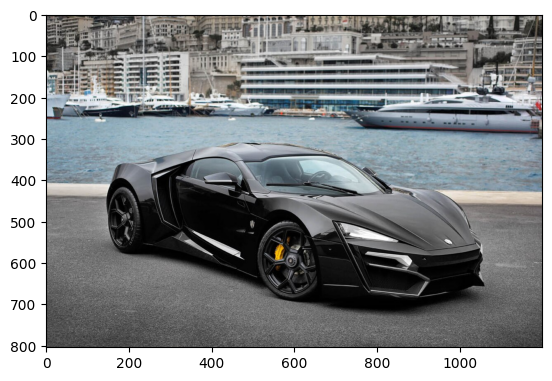

In [4]:
plt.imshow(img)

model.eval()
# img => transform => (3, 224, 224) => unsqueeze => (1(batch size), 3, 224, 224) => img_in
img_in = transforms(img).unsqueeze(dim=0) # (1, 1000) => (1000)
pred = model(img_in).squeeze()

sorted, idxs = pred.softmax(dim=0).sort(descending=True)
print(f'Index of predicted class -> {idxs[0]}')

In [5]:
# часть исходной модели, чтобы получить карты признаков
new_model = nn.Sequential(
    model.conv1,
    model.bn1,
    model.relu,
    model.maxpool,
    model.layer1,
    model.layer2,
    model.layer3,
    model.layer4,
)

In [6]:
# весовые коэффициенты соответствующие предсказанному классу
weights = model.fc.state_dict()['weight'][idxs[0]]
weights.shape

torch.Size([512])

/tmp/ipython-input-4199255366.py:30: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  img1 = np.transpose(img1, axes=[1, 2, 0]) * arr1 + arr2


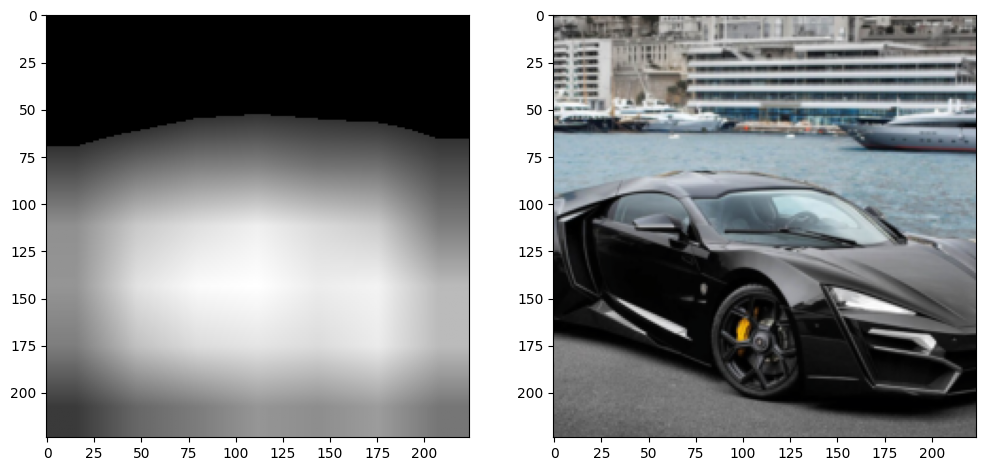

In [10]:
new_model.eval()

img_in = transforms(img).unsqueeze(dim=0)

feature_maps = new_model(img_in)

pred = feature_maps * weights.reshape((feature_maps.shape[1], 1, 1))
pred = pred.sum(dim=1, keepdim=True)

'''
    Сначала увеличиваем размер с (1, 1, 7, 7) до (1, 1, 224, 224)
    с билинейной интерполяцией.
    Далее удаляем все оси имющие только одни элемент.
    Отсоединяем тензор от графа вычислений.
    В конце тензор превращаем в массив numpy с размером (224, 224).
'''
img_numpy = nn.Upsample(scale_factor=32, mode='bilinear')(pred) \
              .squeeze() \
              .detach() \
              .numpy()

# Оставляем значения, которые больше 20% от максимального. Остальные = 0
mask = img_numpy > img_numpy.max()*.2
img_numpy *= mask

# Преобразуем исходное изображение для сравнения.
img1 = transforms(img)
arr1 = np.array([[[0.229, 0.224, 0.225]]])
arr2 = np.array([[[0.485, 0.456, 0.406]]])
img1 = np.transpose(img1, axes=[1, 2, 0]) * arr1 + arr2

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(img_numpy, cmap='grey')
axs[1].imshow(img1)